In [1]:
import pandas as pd
import numpy as np
import warnings
from pathlib import Path


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.covariance import EllipticEnvelope

import matplotlib.pyplot as plt

In [2]:
warnings.filterwarnings('ignore')

In [3]:
# ============================================================
# Paths
# ============================================================

INPUT_PATH = Path("../data/processed/neutral_scoring_prepared/neutral_scoring_input_v1.tsv")
INPUT_RAW = Path("../data/raw/")
MASTER_PATH = Path("../data/processed/master_snv_table_v1.tsv")

OUTPUT_DIR = Path("../results/one_class_neutral_model_results")
OUTPUT_DIR.mkdir(exist_ok=True)

SCORED_OUTPUT = OUTPUT_DIR / "one_class_neutral_scores_v1.tsv"
THRESHOLD_OUTPUT = OUTPUT_DIR / "one_class_neutral_thresholds_v1.tsv"
ENRICHMENT_OUTPUT = OUTPUT_DIR / "one_class_posthoc_enrichment_v1.tsv"
TOP100_OUTPUT = OUTPUT_DIR / "top_100_one_class_outliers_v1.tsv"

PHYLOP30WAY_PATH = INPUT_RAW / "phyloP30way.tsv"
PHYLOP100WAY_PATH = INPUT_RAW / "phyloP100way.tsv"
PHYLOPSSREV30WAY_PATH = INPUT_RAW / "phyloPSSREV30way.tsv"

PHYLOP_COMPARISON_OUTPUT = OUTPUT_DIR / "one_class_phyloP_model_comparison_T95_v1.tsv"
PHYLOP_COMPARISON_SUMMARY_OUTPUT = OUTPUT_DIR / "one_class_phyloP_model_comparison_summary_T95_v1.tsv"
PHYLOP_ENRICHMENT_OUTPUT = OUTPUT_DIR / "one_class_phyloP_posthoc_enrichment_T95_v1.tsv"

# ============================================================
# Load data
# ============================================================

df = pd.read_csv(INPUT_PATH, sep="\t", low_memory=False)

print("Input shape:", df.shape)
print("\nAnalysis group distribution:")
print(df["analysis_group"].value_counts(dropna=False))

Input shape: (49704, 40)

Analysis group distribution:
analysis_group
unlabeled_or_other            41280
neutral_reference              8284
article_pathogenic_posthoc       84
disease_suspected_posthoc        56
Name: count, dtype: int64


In [4]:
gene_annotation_cols = [
    "variant_id",
    "gene_constraint_symbol",
    "gene_constraint_start_position",
    "gene_constraint_end_position",
    "gene_constraint_consequence",
]

gene_annotation = pd.read_csv(
    MASTER_PATH,
    sep="\t",
    usecols=gene_annotation_cols,
    low_memory=False,
)

gene_annotation = gene_annotation.drop_duplicates("variant_id")

df = df.merge(
    gene_annotation,
    on="variant_id",
    how="left",
    validate="one_to_one",
)

In [5]:
# ============================================================
# Load UCSC phyloP scores
# ============================================================

def load_ucsc_phylop_table(path, score_col):
    """
    Load UCSC phyloP bedGraph-like table.

    Expected format:
        track name="..."
        chrom    start    end    value

    Coordinates:
        start is 0-based
        end is non-inclusive
        mtDNA 1-based position = start + 1
    """
    df = pd.read_csv(path, sep="\t", skiprows=1)

    required_cols = {"chrom", "start", "end", "value"}
    missing_cols = required_cols - set(df.columns)

    if missing_cols:
        raise ValueError(
            f"{path} is missing required columns: {missing_cols}"
        )

    df = df.copy()

    df["chrom"] = df["chrom"].astype(str).str.replace('"', "", regex=False)
    df["start"] = pd.to_numeric(df["start"], errors="coerce")
    df["end"] = pd.to_numeric(df["end"], errors="coerce")
    df[score_col] = pd.to_numeric(df["value"], errors="coerce")

    # UCSC/BED-like coordinates:
    # one-base interval [start, end) corresponds to 1-based position start + 1.
    df["position"] = df["start"].astype("Int64") + 1

    df = df[["position", score_col]].copy()

    if df["position"].duplicated().any():
        duplicated_positions = df.loc[
            df["position"].duplicated(),
            "position",
        ].head(10).tolist()

        raise ValueError(
            f"Duplicated positions found in {path}: "
            f"{duplicated_positions}"
        )

    print(f"\nLoaded {score_col}:")
    print(df.shape)
    print(df[score_col].describe())

    return df


phylop30 = load_ucsc_phylop_table(
    PHYLOP30WAY_PATH,
    "phyloP30way",
)

phylop100 = load_ucsc_phylop_table(
    PHYLOP100WAY_PATH,
    "phyloP100way",
)

phylop_ssrev30 = load_ucsc_phylop_table(
    PHYLOPSSREV30WAY_PATH,
    "phyloPSSREV30way",
)


Loaded phyloP30way:
(16569, 2)
count    16569.000000
mean        -1.029540
std          2.438277
min        -14.913000
25%         -1.906610
50%         -0.139512
75%          0.871449
max          1.219000
Name: phyloP30way, dtype: float64

Loaded phyloP100way:
(16569, 2)
count    16569.000000
mean         0.547975
std          5.735464
min        -20.000000
25%         -2.034750
50%          0.651850
75%          5.269390
max          9.631000
Name: phyloP100way, dtype: float64

Loaded phyloPSSREV30way:
(16569, 2)
count    16569.000000
mean        -0.991633
std          2.379868
min        -14.913000
25%         -1.852060
50%         -0.089528
75%          0.910677
max          1.140000
Name: phyloPSSREV30way, dtype: float64


In [6]:
# ============================================================
# Feature engineering
# ============================================================

work = df.copy()

required_cols = [
    "variant_id",
    "position",
    "reference",
    "alternate",
    "validation_label",
    "is_neutral_dataset8",
    "is_pathogenic_dataset9",
    "is_disease_suspected_dataset3",
    "analysis_group",

    "mlc_score",
    "pop_af_max",
    "pop_af_hom_max",
    "pop_af_het_max",
]

missing_cols = [col for col in required_cols if col not in work.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

numeric_cols = [
    "mlc_score",
    "pop_af_max",
    "pop_af_hom_max",
    "pop_af_het_max",
]

for col in numeric_cols:
    work[col] = pd.to_numeric(work[col], errors="coerce")

missing_summary = work[numeric_cols].isna().sum()
missing_summary = missing_summary[missing_summary > 0]

if len(missing_summary) > 0:
    raise ValueError(f"Missing values in numeric features:\n{missing_summary}")

eps = 1e-6

work["rarity_soft"] = -np.log10(work["pop_af_max"] + eps)
work["rarity_soft"] = work["rarity_soft"].clip(lower=0, upper=6)

work["hom_rarity_soft"] = -np.log10(work["pop_af_hom_max"] + eps)
work["hom_rarity_soft"] = work["hom_rarity_soft"].clip(lower=0, upper=6)

work["het_rarity_soft"] = -np.log10(work["pop_af_het_max"] + eps)
work["het_rarity_soft"] = work["het_rarity_soft"].clip(lower=0, upper=6)

work["no_homoplasmic_signal"] = (
    work["pop_af_hom_max"] == 0
).astype(int)

In [7]:
# ============================================================
# Merge UCSC phyloP scores into work table
# ============================================================

work["position"] = pd.to_numeric(work["position"], errors="coerce").astype("Int64")

work = work.merge(
    phylop30,
    on="position",
    how="left",
)

work = work.merge(
    phylop100,
    on="position",
    how="left",
)

work = work.merge(
    phylop_ssrev30,
    on="position",
    how="left",
)

phylop_cols = [
    "phyloP30way",
    "phyloP100way",
    "phyloPSSREV30way",
]

print("\nMissing phyloP values after merge:")
print(work[phylop_cols].isna().sum())

print("\nphyloP summary after merge:")
print(work[phylop_cols].describe())

print("\nphyloP by analysis group:")
print(
    work
    .groupby("analysis_group")[phylop_cols]
    .agg(["count", "mean", "median", "std"])
)


Missing phyloP values after merge:
phyloP30way         0
phyloP100way        0
phyloPSSREV30way    0
dtype: int64

phyloP summary after merge:
        phyloP30way  phyloP100way  phyloPSSREV30way
count  49704.000000  49704.000000      49704.000000
mean      -1.029601      0.547896         -0.991696
std        2.438289      5.735512          2.379878
min      -14.913000    -20.000000        -14.913000
25%       -1.906610     -2.034750         -1.852060
50%       -0.139512      0.651850         -0.089528
75%        0.871449      5.269390          0.910677
max        1.219000      9.631000          1.140000

phyloP by analysis group:
                           phyloP30way                                \
                                 count      mean    median       std   
analysis_group                                                         
article_pathogenic_posthoc          84  0.161121  0.148969  1.114890   
disease_suspected_posthoc           56 -0.669429  0.031087  1.902735   
n

In [8]:
# ============================================================
# CDS-aware codon-position features
# ============================================================
# Previous version used absolute mtDNA coordinate:
#     position % 3
#
# This is not correct for coding interpretation, because protein
# translation starts from the beginning of each gene/CDS, not from
# mtDNA coordinate 1.
#
# New logic:
#     relative_nt_position = position - gene_start + 1
#     codon_position = ((relative_nt_position - 1) % 3) + 1
#
# For MT-ND6, which is encoded on the reverse strand, the coding
# direction is opposite to the reference coordinate direction:
#     relative_nt_position = gene_end - position + 1

work["position_numeric"] = pd.to_numeric(
    work["position"],
    errors="coerce",
)

work["gene_constraint_start_position"] = pd.to_numeric(
    work["gene_constraint_start_position"],
    errors="coerce",
)

work["gene_constraint_end_position"] = pd.to_numeric(
    work["gene_constraint_end_position"],
    errors="coerce",
)

work["gene_constraint_symbol_clean"] = (
    work["gene_constraint_symbol"]
    .astype(str)
    .str.upper()
    .str.replace(" ", "", regex=False)
)

# Protein-coding variants are those with gene-level constraint coordinates.
# Non-coding variants will receive codon_position_simple = "noncoding".
work["is_coding_gene_constraint"] = (
    work["gene_constraint_start_position"].notna()
    & work["gene_constraint_end_position"].notna()
).astype(int)

# Most human mtDNA protein-coding genes are on the forward strand.
# MT-ND6 is the important reverse-strand exception.
reverse_strand_genes = {
    "MT-ND6",
    "ND6",
}

work["is_reverse_strand_gene"] = (
    work["gene_constraint_symbol_clean"].isin(reverse_strand_genes)
).astype(int)

work["gene_relative_nt_position"] = np.nan

forward_mask = (
    (work["is_coding_gene_constraint"] == 1)
    & (work["is_reverse_strand_gene"] == 0)
)

reverse_mask = (
    (work["is_coding_gene_constraint"] == 1)
    & (work["is_reverse_strand_gene"] == 1)
)

# Forward-strand coding genes:
# first coding nucleotide = gene start
work.loc[forward_mask, "gene_relative_nt_position"] = (
    work.loc[forward_mask, "position_numeric"]
    - work.loc[forward_mask, "gene_constraint_start_position"]
    + 1
)

# Reverse-strand coding gene MT-ND6:
# first coding nucleotide is at the higher coordinate end
work.loc[reverse_mask, "gene_relative_nt_position"] = (
    work.loc[reverse_mask, "gene_constraint_end_position"]
    - work.loc[reverse_mask, "position_numeric"]
    + 1
)

# Keep legacy column name for downstream compatibility.
# Now it is gene-frame modulo, not absolute mtDNA-coordinate modulo.
work["position_mod3"] = np.nan

coding_mask = work["gene_relative_nt_position"].notna()

work.loc[coding_mask, "position_mod3"] = (
    work.loc[coding_mask, "gene_relative_nt_position"] % 3
)

work["codon_pos1_any"] = (work["position_mod3"] == 1).astype(int)
work["codon_pos2_any"] = (work["position_mod3"] == 2).astype(int)
work["codon_pos3_any"] = (work["position_mod3"] == 0).astype(int)

work["codon_position_simple"] = np.select(
    [
        work["position_mod3"] == 1,
        work["position_mod3"] == 2,
        work["position_mod3"] == 0,
    ],
    [
        "pos1",
        "pos2",
        "pos3",
    ],
    default="noncoding",
)

print("\nCDS-aware codon-position feature distribution:")
print(work["codon_position_simple"].value_counts(dropna=False))

print("\nCDS-aware codon-position features by analysis group:")
print(
    pd.crosstab(
        work["analysis_group"],
        work["codon_position_simple"],
        dropna=False,
    )
)


CDS-aware codon-position feature distribution:
codon_position_simple
pos1         15375
pos2         15366
pos3         15330
noncoding     3633
Name: count, dtype: int64

CDS-aware codon-position features by analysis group:
codon_position_simple       noncoding   pos1   pos2  pos3
analysis_group                                           
article_pathogenic_posthoc          0     36     36    12
disease_suspected_posthoc           0     35     21     0
neutral_reference                 710   1209    643  5722
unlabeled_or_other               2923  14095  14666  9596


In [9]:
# ============================================================
# Feature sets: codon-mod3 baseline vs + UCSC phyloP scores
# ============================================================

base_feature_cols = [
    "mlc_score",
    "rarity_soft",
    "hom_rarity_soft",
    "het_rarity_soft",
    "no_homoplasmic_signal",

    # Simplified codon-position-like features
    "codon_pos1_any",
    "codon_pos2_any",
    "codon_pos3_any",
]

feature_sets = {
    "codon_mod3_baseline": base_feature_cols,

    "codon_mod3_plus_phyloP30way": (
        base_feature_cols
        + ["phyloP30way"]
    ),

    "codon_mod3_plus_phyloP100way": (
        base_feature_cols
        + ["phyloP100way"]
    ),

    "codon_mod3_plus_phyloPSSREV30way": (
        base_feature_cols
        + ["phyloPSSREV30way"]
    ),

    "codon_mod3_plus_all_phyloP": (
        base_feature_cols
        + [
            "phyloP30way",
            "phyloP100way",
            "phyloPSSREV30way",
        ]
    ),
}

print("\nFeature sets:")
for feature_set_name, cols in feature_sets.items():
    print(f"\n{feature_set_name}")
    for col in cols:
        print("-", col)


Feature sets:

codon_mod3_baseline
- mlc_score
- rarity_soft
- hom_rarity_soft
- het_rarity_soft
- no_homoplasmic_signal
- codon_pos1_any
- codon_pos2_any
- codon_pos3_any

codon_mod3_plus_phyloP30way
- mlc_score
- rarity_soft
- hom_rarity_soft
- het_rarity_soft
- no_homoplasmic_signal
- codon_pos1_any
- codon_pos2_any
- codon_pos3_any
- phyloP30way

codon_mod3_plus_phyloP100way
- mlc_score
- rarity_soft
- hom_rarity_soft
- het_rarity_soft
- no_homoplasmic_signal
- codon_pos1_any
- codon_pos2_any
- codon_pos3_any
- phyloP100way

codon_mod3_plus_phyloPSSREV30way
- mlc_score
- rarity_soft
- hom_rarity_soft
- het_rarity_soft
- no_homoplasmic_signal
- codon_pos1_any
- codon_pos2_any
- codon_pos3_any
- phyloPSSREV30way

codon_mod3_plus_all_phyloP
- mlc_score
- rarity_soft
- hom_rarity_soft
- het_rarity_soft
- no_homoplasmic_signal
- codon_pos1_any
- codon_pos2_any
- codon_pos3_any
- phyloP30way
- phyloP100way
- phyloPSSREV30way


In [10]:
# ============================================================
# Split neutral_reference into train and validation
# ============================================================

neutral_df = work[work["analysis_group"] == "neutral_reference"].copy()

print("\nNeutral reference size:", neutral_df.shape)

neutral_train_idx, neutral_val_idx = train_test_split(
    neutral_df.index,
    test_size=0.25,
    random_state=42,
)

print("Neutral train size:", len(neutral_train_idx))
print("Neutral validation size:", len(neutral_val_idx))

work["neutral_split"] = "not_neutral_reference"
work.loc[neutral_train_idx, "neutral_split"] = "neutral_train"
work.loc[neutral_val_idx, "neutral_split"] = "neutral_validation"

print("\nNeutral split distribution:")
print(work["neutral_split"].value_counts())


Neutral reference size: (8284, 61)
Neutral train size: 6213
Neutral validation size: 2071

Neutral split distribution:
neutral_split
not_neutral_reference    41420
neutral_train             6213
neutral_validation        2071
Name: count, dtype: int64


In [11]:
# ============================================================
# One-class model helper
# ============================================================

def fit_score_isolation_forest(data, train_idx, feature_cols, model_name):
    X_train = data.loc[train_idx, feature_cols]
    X_all = data[feature_cols]

    model = Pipeline([
        ("scaler", RobustScaler()),
        ("model", IsolationForest(
            n_estimators=500,
            contamination="auto",
            random_state=42,
            n_jobs=-1,
        )),
    ])

    model.fit(X_train)

    # decision_function: larger = more normal
    normality_score = model.decision_function(X_all)

    # outlier score: larger = more out-of-neutral-domain
    outlier_score = -normality_score

    return outlier_score, model


def fit_score_elliptic_envelope(data, train_idx, feature_cols, model_name):
    X_train = data.loc[train_idx, feature_cols]
    X_all = data[feature_cols]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", EllipticEnvelope(
            contamination=0.05,
            random_state=42,
            support_fraction=None,
        )),
    ])

    model.fit(X_train)

    # decision_function: larger = more normal
    normality_score = model.decision_function(X_all)

    # outlier score: larger = more out-of-neutral-domain
    outlier_score = -normality_score

    return outlier_score, model

In [12]:
# ============================================================
# Fit one-class models for phyloP ablation
# ============================================================

scored = work.copy()

score_specs = {}

for feature_set_name, cols in feature_sets.items():

    print(f"\nFitting feature set: {feature_set_name}")
    print("Features:", cols)

    missing_feature_cols = [col for col in cols if col not in scored.columns]

    if missing_feature_cols:
        raise ValueError(
            f"Missing feature columns for {feature_set_name}: "
            f"{missing_feature_cols}"
        )

    # ----------------------------
    # Isolation Forest
    # ----------------------------
    model_name = f"{feature_set_name}__isolation_forest"
    score_col = f"{model_name}_outlier_score"

    iso_score, iso_model = fit_score_isolation_forest(
        scored,
        neutral_train_idx,
        cols,
        model_name=model_name,
    )

    scored[score_col] = iso_score

    score_specs[model_name] = {
        "score_col": score_col,
        "model": iso_model,
        "feature_set": feature_set_name,
        "base_model": "isolation_forest",
        "feature_cols": cols,
    }

    # ----------------------------
    # Elliptic Envelope
    # ----------------------------
    model_name = f"{feature_set_name}__elliptic_envelope"
    score_col = f"{model_name}_outlier_score"

    ell_score, ell_model = fit_score_elliptic_envelope(
        scored,
        neutral_train_idx,
        cols,
        model_name=model_name,
    )

    scored[score_col] = ell_score

    score_specs[model_name] = {
        "score_col": score_col,
        "model": ell_model,
        "feature_set": feature_set_name,
        "base_model": "elliptic_envelope",
        "feature_cols": cols,
    }

print("\nFitted models:")
for model_name, spec in score_specs.items():
    print(
        model_name,
        "| feature_set:",
        spec["feature_set"],
        "| base_model:",
        spec["base_model"],
        "| score_col:",
        spec["score_col"],
    )


Fitting feature set: codon_mod3_baseline
Features: ['mlc_score', 'rarity_soft', 'hom_rarity_soft', 'het_rarity_soft', 'no_homoplasmic_signal', 'codon_pos1_any', 'codon_pos2_any', 'codon_pos3_any']

Fitting feature set: codon_mod3_plus_phyloP30way
Features: ['mlc_score', 'rarity_soft', 'hom_rarity_soft', 'het_rarity_soft', 'no_homoplasmic_signal', 'codon_pos1_any', 'codon_pos2_any', 'codon_pos3_any', 'phyloP30way']

Fitting feature set: codon_mod3_plus_phyloP100way
Features: ['mlc_score', 'rarity_soft', 'hom_rarity_soft', 'het_rarity_soft', 'no_homoplasmic_signal', 'codon_pos1_any', 'codon_pos2_any', 'codon_pos3_any', 'phyloP100way']

Fitting feature set: codon_mod3_plus_phyloPSSREV30way
Features: ['mlc_score', 'rarity_soft', 'hom_rarity_soft', 'het_rarity_soft', 'no_homoplasmic_signal', 'codon_pos1_any', 'codon_pos2_any', 'codon_pos3_any', 'phyloPSSREV30way']

Fitting feature set: codon_mod3_plus_all_phyloP
Features: ['mlc_score', 'rarity_soft', 'hom_rarity_soft', 'het_rarity_soft', '

In [13]:
# ============================================================
# Threshold calibration on held-out neutral_validation
# Main interpretation threshold: T95
# ============================================================

threshold_rows = []

validation_mask = scored["neutral_split"] == "neutral_validation"

thresholds = {
    "T95": 0.95,
}

for model_name, spec in score_specs.items():
    score_col = spec["score_col"]
    feature_set_name = spec["feature_set"]
    base_model = spec["base_model"]

    validation_scores = scored.loc[validation_mask, score_col]

    for threshold_name, q in thresholds.items():
        threshold = validation_scores.quantile(q)

        flag_col = f"{model_name}_above_{threshold_name}"

        scored[flag_col] = (
            scored[score_col] > threshold
        ).astype(int)

        n_val_above = int(scored.loc[validation_mask, flag_col].sum())
        frac_val_above = float(scored.loc[validation_mask, flag_col].mean())

        threshold_rows.append({
            "model_name": model_name,
            "feature_set": feature_set_name,
            "base_model": base_model,
            "score_col": score_col,
            "threshold_name": threshold_name,
            "validation_neutral_quantile": q,
            "threshold_value": threshold,
            "n_validation_neutral_above": n_val_above,
            "fraction_validation_neutral_above": frac_val_above,
        })

threshold_df = pd.DataFrame(threshold_rows)

print("\nT95 thresholds:")
print(threshold_df)


T95 thresholds:
                                          model_name  \
0              codon_mod3_baseline__isolation_forest   
1             codon_mod3_baseline__elliptic_envelope   
2      codon_mod3_plus_phyloP30way__isolation_forest   
3     codon_mod3_plus_phyloP30way__elliptic_envelope   
4     codon_mod3_plus_phyloP100way__isolation_forest   
5    codon_mod3_plus_phyloP100way__elliptic_envelope   
6  codon_mod3_plus_phyloPSSREV30way__isolation_fo...   
7  codon_mod3_plus_phyloPSSREV30way__elliptic_env...   
8       codon_mod3_plus_all_phyloP__isolation_forest   
9      codon_mod3_plus_all_phyloP__elliptic_envelope   

                        feature_set         base_model  \
0               codon_mod3_baseline   isolation_forest   
1               codon_mod3_baseline  elliptic_envelope   
2       codon_mod3_plus_phyloP30way   isolation_forest   
3       codon_mod3_plus_phyloP30way  elliptic_envelope   
4      codon_mod3_plus_phyloP100way   isolation_forest   
5      codon_mod3_

In [14]:
# ============================================================
# Post-hoc enrichment by analysis group at T95
# ============================================================

analysis_groups = [
    "neutral_reference",
    "unlabeled_or_other",
    "article_pathogenic_posthoc",
    "disease_suspected_posthoc",
]

expected_fraction = {
    "T95": 0.05,
}

enrichment_rows = []

for model_name, spec in score_specs.items():
    feature_set_name = spec["feature_set"]
    base_model = spec["base_model"]

    for threshold_name in ["T95"]:
        flag_col = f"{model_name}_above_{threshold_name}"
        expected = expected_fraction[threshold_name]

        for group in analysis_groups:
            group_mask = scored["analysis_group"] == group

            n_group = int(group_mask.sum())
            n_above = int(scored.loc[group_mask, flag_col].sum())
            frac_above = n_above / n_group if n_group > 0 else np.nan

            enrichment_rows.append({
                "model_name": model_name,
                "feature_set": feature_set_name,
                "base_model": base_model,
                "threshold_name": threshold_name,
                "analysis_group": group,
                "n_group": n_group,
                "n_above_threshold": n_above,
                "fraction_above_threshold": frac_above,
                "expected_validation_neutral_fraction": expected,
                "fold_enrichment_vs_expected": (
                    frac_above / expected if expected > 0 else np.nan
                ),
            })

enrichment_df = pd.DataFrame(enrichment_rows)

print("\nPost-hoc enrichment at T95:")
print(enrichment_df)

enrichment_df.to_csv(
    PHYLOP_ENRICHMENT_OUTPUT,
    sep="\t",
    index=False,
)

print("\nSaved phyloP enrichment:")
print(PHYLOP_ENRICHMENT_OUTPUT)


Post-hoc enrichment at T95:
                                           model_name  \
0               codon_mod3_baseline__isolation_forest   
1               codon_mod3_baseline__isolation_forest   
2               codon_mod3_baseline__isolation_forest   
3               codon_mod3_baseline__isolation_forest   
4              codon_mod3_baseline__elliptic_envelope   
5              codon_mod3_baseline__elliptic_envelope   
6              codon_mod3_baseline__elliptic_envelope   
7              codon_mod3_baseline__elliptic_envelope   
8       codon_mod3_plus_phyloP30way__isolation_forest   
9       codon_mod3_plus_phyloP30way__isolation_forest   
10      codon_mod3_plus_phyloP30way__isolation_forest   
11      codon_mod3_plus_phyloP30way__isolation_forest   
12     codon_mod3_plus_phyloP30way__elliptic_envelope   
13     codon_mod3_plus_phyloP30way__elliptic_envelope   
14     codon_mod3_plus_phyloP30way__elliptic_envelope   
15     codon_mod3_plus_phyloP30way__elliptic_envelope   
16

In [15]:
# ============================================================
# Compare phyloP feature sets vs codon-mod3 baseline
# ============================================================

reference_feature_set = "codon_mod3_baseline"

baseline_df = (
    enrichment_df[enrichment_df["feature_set"] == reference_feature_set]
    .copy()
)

test_df = (
    enrichment_df[enrichment_df["feature_set"] != reference_feature_set]
    .copy()
)

merge_keys = [
    "base_model",
    "threshold_name",
    "analysis_group",
]

comparison_df = baseline_df.merge(
    test_df,
    on=merge_keys,
    suffixes=("_baseline", "_with_phyloP"),
)

comparison_df["delta_n_above_threshold"] = (
    comparison_df["n_above_threshold_with_phyloP"]
    - comparison_df["n_above_threshold_baseline"]
)

comparison_df["delta_fraction_above_threshold"] = (
    comparison_df["fraction_above_threshold_with_phyloP"]
    - comparison_df["fraction_above_threshold_baseline"]
)

comparison_df["delta_fold_enrichment_vs_expected"] = (
    comparison_df["fold_enrichment_vs_expected_with_phyloP"]
    - comparison_df["fold_enrichment_vs_expected_baseline"]
)

comparison_df["relative_delta_fold_enrichment_percent"] = (
    comparison_df["delta_fold_enrichment_vs_expected"]
    / comparison_df["fold_enrichment_vs_expected_baseline"]
    * 100
)

target_groups = [
    "article_pathogenic_posthoc",
    "disease_suspected_posthoc",
]

def interpret_phyloP_change(row):
    """
    For pathogenic/suspected post-hoc groups:
    higher enrichment above T95 is interpreted as better separation.
    """
    if row["analysis_group"] not in target_groups:
        return "not_primary_target_group"

    delta = row["delta_fold_enrichment_vs_expected"]

    if pd.isna(delta):
        return "not_evaluable"
    elif delta > 0:
        return "better_with_phyloP"
    elif delta < 0:
        return "worse_with_phyloP"
    else:
        return "no_change"

comparison_df["interpretation"] = comparison_df.apply(
    interpret_phyloP_change,
    axis=1,
)

comparison_cols = [
    "base_model",
    "threshold_name",
    "analysis_group",

    "feature_set_baseline",
    "feature_set_with_phyloP",

    "n_group_baseline",

    "n_above_threshold_baseline",
    "n_above_threshold_with_phyloP",
    "delta_n_above_threshold",

    "fraction_above_threshold_baseline",
    "fraction_above_threshold_with_phyloP",
    "delta_fraction_above_threshold",

    "fold_enrichment_vs_expected_baseline",
    "fold_enrichment_vs_expected_with_phyloP",
    "delta_fold_enrichment_vs_expected",
    "relative_delta_fold_enrichment_percent",

    "interpretation",
]

comparison_df = comparison_df[comparison_cols].copy()

print("\nphyloP comparison vs codon-mod3 baseline:")
print(comparison_df)

comparison_df.to_csv(
    PHYLOP_COMPARISON_OUTPUT,
    sep="\t",
    index=False,
)

print("\nSaved phyloP comparison:")
print(PHYLOP_COMPARISON_OUTPUT)


phyloP comparison vs codon-mod3 baseline:
           base_model threshold_name              analysis_group  \
0    isolation_forest            T95           neutral_reference   
1    isolation_forest            T95           neutral_reference   
2    isolation_forest            T95           neutral_reference   
3    isolation_forest            T95           neutral_reference   
4    isolation_forest            T95          unlabeled_or_other   
5    isolation_forest            T95          unlabeled_or_other   
6    isolation_forest            T95          unlabeled_or_other   
7    isolation_forest            T95          unlabeled_or_other   
8    isolation_forest            T95  article_pathogenic_posthoc   
9    isolation_forest            T95  article_pathogenic_posthoc   
10   isolation_forest            T95  article_pathogenic_posthoc   
11   isolation_forest            T95  article_pathogenic_posthoc   
12   isolation_forest            T95   disease_suspected_posthoc   
13   

In [16]:
# ============================================================
# Compact summary: did UCSC phyloP improve T95 separation?
# ============================================================

focus_df = comparison_df[
    comparison_df["analysis_group"].isin(target_groups)
    & (comparison_df["threshold_name"] == "T95")
].copy()

summary_df = (
    focus_df
    .groupby(
        [
            "base_model",
            "feature_set_with_phyloP",
            "threshold_name",
        ],
        as_index=False,
    )
    .agg(
        mean_delta_fraction_above_threshold=(
            "delta_fraction_above_threshold",
            "mean",
        ),
        mean_delta_fold_enrichment_vs_expected=(
            "delta_fold_enrichment_vs_expected",
            "mean",
        ),
        n_target_groups_better=(
            "interpretation",
            lambda x: int((x == "better_with_phyloP").sum()),
        ),
        n_target_groups_worse=(
            "interpretation",
            lambda x: int((x == "worse_with_phyloP").sum()),
        ),
        n_target_groups_no_change=(
            "interpretation",
            lambda x: int((x == "no_change").sum()),
        ),
    )
)

def overall_phyloP_interpretation(row):
    if row["mean_delta_fold_enrichment_vs_expected"] > 0:
        return "overall_better_with_phyloP"
    elif row["mean_delta_fold_enrichment_vs_expected"] < 0:
        return "overall_worse_with_phyloP"
    else:
        return "overall_no_change"

summary_df["overall_interpretation"] = summary_df.apply(
    overall_phyloP_interpretation,
    axis=1,
)

summary_df = summary_df.sort_values(
    [
        "base_model",
        "mean_delta_fold_enrichment_vs_expected",
    ],
    ascending=[True, False],
)

print("\nCompact phyloP comparison summary:")
print(summary_df)

summary_df.to_csv(
    PHYLOP_COMPARISON_SUMMARY_OUTPUT,
    sep="\t",
    index=False,
)

print("\nSaved phyloP comparison summary:")
print(PHYLOP_COMPARISON_SUMMARY_OUTPUT)


Compact phyloP comparison summary:
          base_model           feature_set_with_phyloP threshold_name  \
0  elliptic_envelope        codon_mod3_plus_all_phyloP            T95   
3  elliptic_envelope  codon_mod3_plus_phyloPSSREV30way            T95   
1  elliptic_envelope      codon_mod3_plus_phyloP100way            T95   
2  elliptic_envelope       codon_mod3_plus_phyloP30way            T95   
4   isolation_forest        codon_mod3_plus_all_phyloP            T95   
5   isolation_forest      codon_mod3_plus_phyloP100way            T95   
6   isolation_forest       codon_mod3_plus_phyloP30way            T95   
7   isolation_forest  codon_mod3_plus_phyloPSSREV30way            T95   

   mean_delta_fraction_above_threshold  \
0                             0.125000   
3                             0.062500   
1                             0.053571   
2                             0.053571   
4                             0.101190   
5                             0.083333   
6           

In [17]:
# ============================================================
# Save final scored table for downstream spectrum analysis
# Final model: Isolation Forest + codon position + phyloP100way
# Main threshold: T95
# ============================================================

FINAL_MODEL_NAME = "codon_mod3_plus_phyloP100way__isolation_forest"

FINAL_SCORED_OUTPUT = (
    OUTPUT_DIR / "one_class_neutral_scores_final_isolation_forest_phyloP100way_T95_v1.tsv"
)

FINAL_THRESHOLD_OUTPUT = (
    OUTPUT_DIR / "one_class_neutral_threshold_final_isolation_forest_phyloP100way_T95_v1.tsv"
)

# ------------------------------------------------------------
# Check that final model exists
# ------------------------------------------------------------

required_final_model_cols = [
    f"{FINAL_MODEL_NAME}_outlier_score",
    f"{FINAL_MODEL_NAME}_above_T95",
]

missing_final_model_cols = [
    col for col in required_final_model_cols
    if col not in scored.columns
]

if missing_final_model_cols:
    raise ValueError(
        "Final model columns are missing from scored table: "
        f"{missing_final_model_cols}\n"
        "Check that the phyloP100way Isolation Forest model was fitted "
        "and T95 threshold was calculated."
    )

# ------------------------------------------------------------
# Add rank and percentile for final model if needed
# ------------------------------------------------------------

final_score_col = f"{FINAL_MODEL_NAME}_outlier_score"
final_rank_col = f"{FINAL_MODEL_NAME}_rank"
final_percentile_col = f"{FINAL_MODEL_NAME}_percentile"

if final_rank_col not in scored.columns:
    scored[final_rank_col] = scored[final_score_col].rank(
        ascending=False,
        method="min",
    )

if final_percentile_col not in scored.columns:
    scored[final_percentile_col] = scored[final_score_col].rank(
        pct=True,
        ascending=True,
    )

# ------------------------------------------------------------
# Create final scored table with simplified column names
# ------------------------------------------------------------

final_scored = scored.copy()

final_scored["isolation_forest_outlier_score"] = (
    final_scored[f"{FINAL_MODEL_NAME}_outlier_score"]
)

final_scored["isolation_forest_rank"] = (
    final_scored[f"{FINAL_MODEL_NAME}_rank"]
)

final_scored["isolation_forest_percentile"] = (
    final_scored[f"{FINAL_MODEL_NAME}_percentile"]
)

final_scored["isolation_forest_above_T95"] = (
    final_scored[f"{FINAL_MODEL_NAME}_above_T95"]
)

# ------------------------------------------------------------
# Output columns
# ------------------------------------------------------------

base_cols = [
    "variant_id",
    "position",
    "reference",
    "alternate",
    "validation_label",
    "is_neutral_dataset8",
    "is_pathogenic_dataset9",
    "is_disease_suspected_dataset3",
    "analysis_group",
    "neutral_split",
]

annotation_cols = [
    # Supplementary Dataset 3 annotation
    # Used only for post-hoc interpretation, not as model feature.
    "Classification_group",

    # Simplified codon-position annotation
    "position_mod3",
    "codon_position_simple",
]

feature_cols_final = [
    "mlc_score",

    "pop_af_max",
    "pop_af_hom_max",
    "pop_af_het_max",

    "rarity_soft",
    "hom_rarity_soft",
    "het_rarity_soft",
    "no_homoplasmic_signal",

    "codon_pos1_any",
    "codon_pos2_any",
    "codon_pos3_any",

    "phyloP100way",
]

model_output_cols = [
    "isolation_forest_outlier_score",
    "isolation_forest_rank",
    "isolation_forest_percentile",
    "isolation_forest_above_T95",
]

final_output_cols = (
    [col for col in base_cols if col in final_scored.columns]
    + [col for col in annotation_cols if col in final_scored.columns]
    + [col for col in feature_cols_final if col in final_scored.columns]
    + model_output_cols
)

missing_final_output_cols = [
    col for col in final_output_cols
    if col not in final_scored.columns
]

if missing_final_output_cols:
    raise ValueError(
        f"Missing final output columns: {missing_final_output_cols}"
    )

# ------------------------------------------------------------
# Save final scored table
# ------------------------------------------------------------

final_scored[final_output_cols].to_csv(
    FINAL_SCORED_OUTPUT,
    sep="\t",
    index=False,
)

print("\nSaved final scored table:")
print(FINAL_SCORED_OUTPUT)

print("\nFinal scored table shape:")
print(final_scored[final_output_cols].shape)

print("\nFinal scored table columns:")
for col in final_output_cols:
    print("-", col)

# ------------------------------------------------------------
# Save final T95 threshold only
# ------------------------------------------------------------

final_threshold_df = threshold_df[
    (threshold_df["model_name"] == FINAL_MODEL_NAME)
    & (threshold_df["threshold_name"] == "T95")
].copy()

if final_threshold_df.empty:
    raise ValueError(
        f"No T95 threshold found for final model: {FINAL_MODEL_NAME}"
    )

final_threshold_df = final_threshold_df.copy()
final_threshold_df["final_model_alias"] = "isolation_forest"

final_threshold_df.to_csv(
    FINAL_THRESHOLD_OUTPUT,
    sep="\t",
    index=False,
)

print("\nSaved final threshold:")
print(FINAL_THRESHOLD_OUTPUT)

print("\nFinal T95 threshold:")
print(final_threshold_df)


Saved final scored table:
..\results\one_class_neutral_model_results\one_class_neutral_scores_final_isolation_forest_phyloP100way_T95_v1.tsv

Final scored table shape:
(49704, 28)

Final scored table columns:
- variant_id
- position
- reference
- alternate
- validation_label
- is_neutral_dataset8
- is_pathogenic_dataset9
- is_disease_suspected_dataset3
- analysis_group
- neutral_split
- position_mod3
- codon_position_simple
- mlc_score
- pop_af_max
- pop_af_hom_max
- pop_af_het_max
- rarity_soft
- hom_rarity_soft
- het_rarity_soft
- no_homoplasmic_signal
- codon_pos1_any
- codon_pos2_any
- codon_pos3_any
- phyloP100way
- isolation_forest_outlier_score
- isolation_forest_rank
- isolation_forest_percentile
- isolation_forest_above_T95

Saved final threshold:
..\results\one_class_neutral_model_results\one_class_neutral_threshold_final_isolation_forest_phyloP100way_T95_v1.tsv

Final T95 threshold:
                                       model_name  \
4  codon_mod3_plus_phyloP100way__isolat

In [18]:
# ============================================================
# Visualization: phyloP comparison for Isolation Forest at T95
# ============================================================

PHYLOP_PLOT_DIR = OUTPUT_DIR / "phyloP_isolation_forest_plots_T95"
PHYLOP_PLOT_DIR.mkdir(parents=True, exist_ok=True)

phylo_feature_order = [
    "codon_mod3_plus_phyloP30way",
    "codon_mod3_plus_phyloP100way",
    "codon_mod3_plus_phyloPSSREV30way",
    "codon_mod3_plus_all_phyloP",
]

phylo_feature_labels = {
    "codon_mod3_plus_phyloP30way": "phyloP30way",
    "codon_mod3_plus_phyloP100way": "phyloP100way",
    "codon_mod3_plus_phyloPSSREV30way": "phyloPSSREV30way",
    "codon_mod3_plus_all_phyloP": "all phyloP",
}

target_group_order = [
    "article_pathogenic_posthoc",
    "disease_suspected_posthoc",
]

target_group_labels = {
    "article_pathogenic_posthoc": "Article pathogenic",
    "disease_suspected_posthoc": "Disease suspected",
}


def plot_isolation_forest_phyloP_delta_fold_enrichment(
    comparison_df,
    save_path=None,
):
    """
    Plot change in fold enrichment vs codon-mod3 baseline
    for Isolation Forest at T95.
    """
    plot_df = comparison_df[
        (comparison_df["base_model"] == "isolation_forest")
        & (comparison_df["threshold_name"] == "T95")
        & (comparison_df["analysis_group"].isin(target_group_order))
        & (comparison_df["feature_set_with_phyloP"].isin(phylo_feature_order))
    ].copy()

    if plot_df.empty:
        raise ValueError(
            "No Isolation Forest T95 rows found in comparison_df."
        )

    plot_df["feature_set_with_phyloP"] = pd.Categorical(
        plot_df["feature_set_with_phyloP"],
        categories=phylo_feature_order,
        ordered=True,
    )

    plot_df["analysis_group"] = pd.Categorical(
        plot_df["analysis_group"],
        categories=target_group_order,
        ordered=True,
    )

    plot_df = plot_df.sort_values(
        ["feature_set_with_phyloP", "analysis_group"]
    )

    pivot_df = plot_df.pivot(
        index="feature_set_with_phyloP",
        columns="analysis_group",
        values="delta_fold_enrichment_vs_expected",
    ).loc[phylo_feature_order]

    x = np.arange(pivot_df.shape[0])
    width = 0.35

    plt.figure(figsize=(10, 5))

    for i, group in enumerate(target_group_order):
        offsets = x + (i - 0.5) * width

        plt.bar(
            offsets,
            pivot_df[group].values,
            width=width,
            label=target_group_labels[group],
        )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1,
    )

    plt.xticks(
        x,
        [phylo_feature_labels[f] for f in pivot_df.index],
        rotation=30,
        ha="right",
    )

    plt.ylabel("Delta fold enrichment vs codon baseline")
    plt.title("Isolation Forest: effect of phyloP features at T95")
    plt.legend(fontsize=8)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return pivot_df


def plot_isolation_forest_phyloP_fraction_above_T95(
    enrichment_df,
    save_path=None,
):
    """
    Plot fraction of variants above T95 for codon baseline
    and phyloP-extended Isolation Forest models.
    """
    feature_order = [
        "codon_mod3_baseline",
        "codon_mod3_plus_phyloP30way",
        "codon_mod3_plus_phyloP100way",
        "codon_mod3_plus_phyloPSSREV30way",
        "codon_mod3_plus_all_phyloP",
    ]

    feature_labels = {
        "codon_mod3_baseline": "baseline",
        "codon_mod3_plus_phyloP30way": "phyloP30way",
        "codon_mod3_plus_phyloP100way": "phyloP100way",
        "codon_mod3_plus_phyloPSSREV30way": "phyloPSSREV30way",
        "codon_mod3_plus_all_phyloP": "all phyloP",
    }

    plot_df = enrichment_df[
        (enrichment_df["base_model"] == "isolation_forest")
        & (enrichment_df["threshold_name"] == "T95")
        & (enrichment_df["analysis_group"].isin(target_group_order))
        & (enrichment_df["feature_set"].isin(feature_order))
    ].copy()

    if plot_df.empty:
        raise ValueError(
            "No Isolation Forest T95 rows found in enrichment_df."
        )

    plot_df["feature_set"] = pd.Categorical(
        plot_df["feature_set"],
        categories=feature_order,
        ordered=True,
    )

    plot_df["analysis_group"] = pd.Categorical(
        plot_df["analysis_group"],
        categories=target_group_order,
        ordered=True,
    )

    plot_df = plot_df.sort_values(["feature_set", "analysis_group"])

    pivot_df = plot_df.pivot(
        index="feature_set",
        columns="analysis_group",
        values="fraction_above_threshold",
    ).loc[feature_order]

    x = np.arange(pivot_df.shape[0])
    width = 0.35

    plt.figure(figsize=(10, 5))

    for i, group in enumerate(target_group_order):
        offsets = x + (i - 0.5) * width

        plt.bar(
            offsets,
            pivot_df[group].values,
            width=width,
            label=target_group_labels[group],
        )

    plt.axhline(
        0.05,
        linestyle="--",
        linewidth=1,
        label="Neutral expectation at T95",
    )

    plt.xticks(
        x,
        [feature_labels[f] for f in pivot_df.index],
        rotation=30,
        ha="right",
    )

    plt.ylabel("Fraction above T95")
    plt.title("Isolation Forest: fraction above T95 by phyloP feature set")
    plt.legend(fontsize=8)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return pivot_df


def plot_isolation_forest_phyloP_mean_delta_summary(
    summary_df,
    save_path=None,
):
    """
    Plot mean delta fold enrichment across target groups
    for Isolation Forest at T95.
    """
    plot_df = summary_df[
        (summary_df["base_model"] == "isolation_forest")
        & (summary_df["threshold_name"] == "T95")
        & (summary_df["feature_set_with_phyloP"].isin(phylo_feature_order))
    ].copy()

    if plot_df.empty:
        raise ValueError(
            "No Isolation Forest T95 rows found in summary_df."
        )

    plot_df["feature_set_with_phyloP"] = pd.Categorical(
        plot_df["feature_set_with_phyloP"],
        categories=phylo_feature_order,
        ordered=True,
    )

    plot_df = plot_df.sort_values("feature_set_with_phyloP")

    x = np.arange(plot_df.shape[0])
    y = plot_df["mean_delta_fold_enrichment_vs_expected"].values

    plt.figure(figsize=(9, 5))

    plt.bar(x, y)

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1,
    )

    plt.xticks(
        x,
        [
            phylo_feature_labels[f]
            for f in plot_df["feature_set_with_phyloP"]
        ],
        rotation=30,
        ha="right",
    )

    plt.ylabel("Mean delta fold enrichment vs codon baseline")
    plt.title("Isolation Forest: mean phyloP effect at T95")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return plot_df

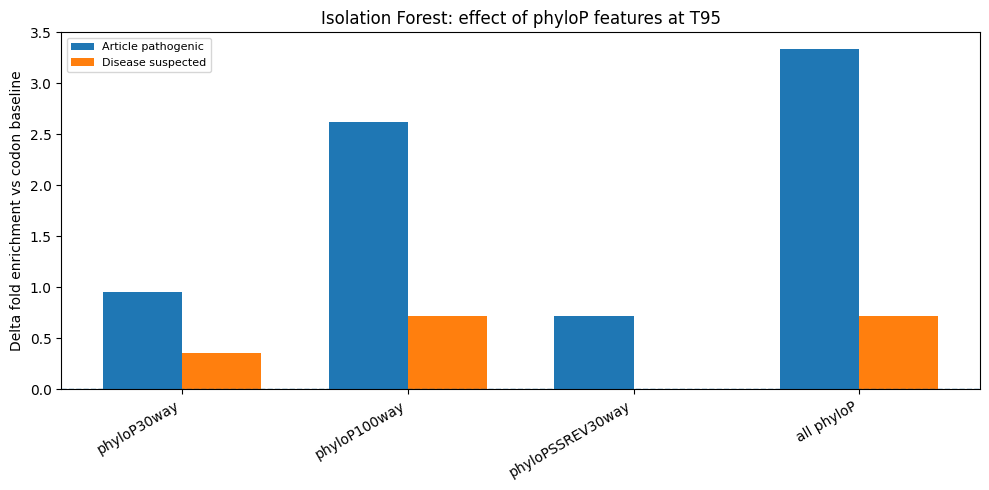

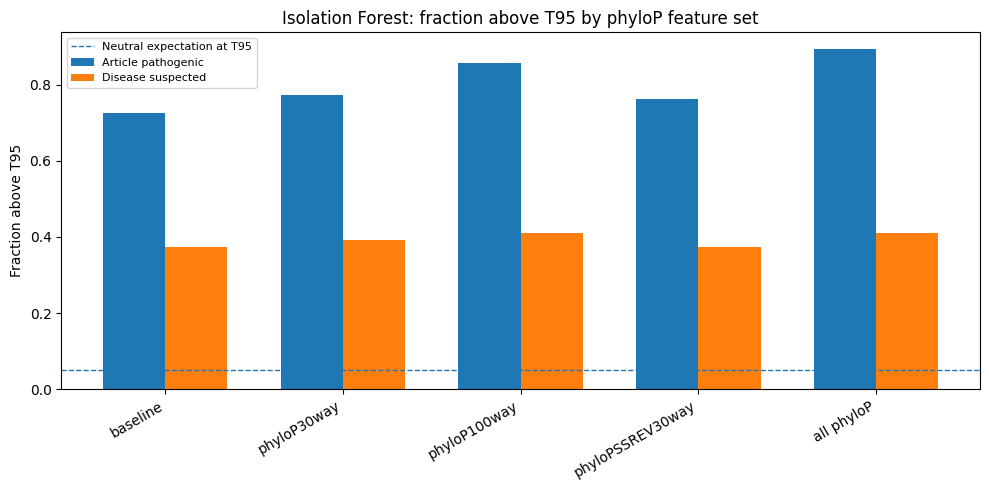

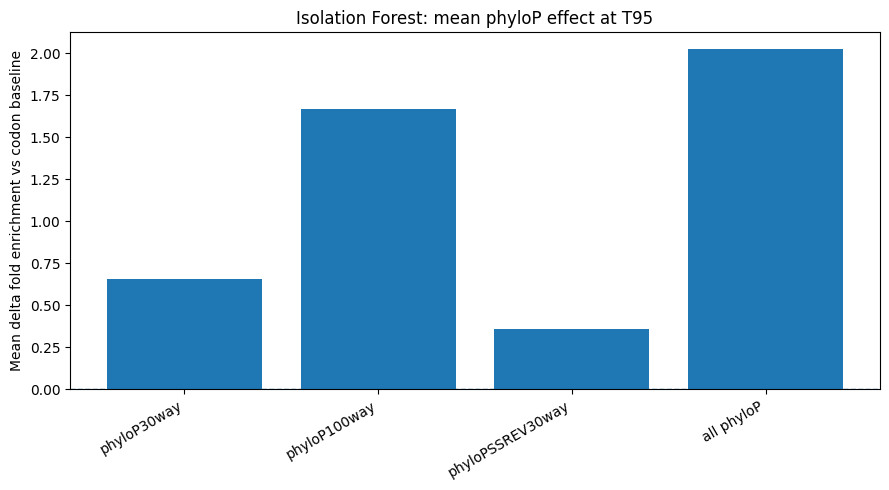


Isolation Forest delta fold enrichment pivot:
analysis_group                    article_pathogenic_posthoc  \
feature_set_with_phyloP                                        
codon_mod3_plus_phyloP30way                         0.952381   
codon_mod3_plus_phyloP100way                        2.619048   
codon_mod3_plus_phyloPSSREV30way                    0.714286   
codon_mod3_plus_all_phyloP                          3.333333   

analysis_group                    disease_suspected_posthoc  
feature_set_with_phyloP                                      
codon_mod3_plus_phyloP30way                        0.357143  
codon_mod3_plus_phyloP100way                       0.714286  
codon_mod3_plus_phyloPSSREV30way                   0.000000  
codon_mod3_plus_all_phyloP                         0.714286  

Isolation Forest fraction above T95 pivot:
analysis_group                    article_pathogenic_posthoc  \
feature_set                                                    
codon_mod3_baseline     

In [19]:
# ============================================================
# Generate Isolation Forest phyloP comparison plots
# ============================================================

if_delta_pivot = plot_isolation_forest_phyloP_delta_fold_enrichment(
    comparison_df=comparison_df,
    save_path=PHYLOP_PLOT_DIR / "isolation_forest_phyloP_delta_fold_enrichment_T95.png",
)

if_fraction_pivot = plot_isolation_forest_phyloP_fraction_above_T95(
    enrichment_df=enrichment_df,
    save_path=PHYLOP_PLOT_DIR / "isolation_forest_phyloP_fraction_above_T95.png",
)

if_summary_plot_df = plot_isolation_forest_phyloP_mean_delta_summary(
    summary_df=summary_df,
    save_path=PHYLOP_PLOT_DIR / "isolation_forest_phyloP_mean_delta_summary_T95.png",
)

print("\nIsolation Forest delta fold enrichment pivot:")
print(if_delta_pivot)

print("\nIsolation Forest fraction above T95 pivot:")
print(if_fraction_pivot)

print("\nIsolation Forest phyloP summary:")
print(if_summary_plot_df)

In [20]:
# ============================================================
# Plotting helpers: Isolation Forest phyloP models, T95 only
# No figure saving
# ============================================================

analysis_group_order = [
    "neutral_reference",
    "unlabeled_or_other",
    "article_pathogenic_posthoc",
    "disease_suspected_posthoc",
]

analysis_group_labels = {
    "neutral_reference": "Neutral reference",
    "unlabeled_or_other": "Unlabeled / other",
    "article_pathogenic_posthoc": "Article pathogenic post-hoc",
    "disease_suspected_posthoc": "Disease suspected post-hoc",
}

phylo_if_feature_order = [
    "codon_mod3_baseline",
    "codon_mod3_plus_phyloP30way",
    "codon_mod3_plus_phyloP100way",
    "codon_mod3_plus_phyloPSSREV30way",
    "codon_mod3_plus_all_phyloP",
]

phylo_if_feature_labels = {
    "codon_mod3_baseline": "baseline",
    "codon_mod3_plus_phyloP30way": "phyloP30way",
    "codon_mod3_plus_phyloP100way": "phyloP100way",
    "codon_mod3_plus_phyloPSSREV30way": "phyloPSSREV30way",
    "codon_mod3_plus_all_phyloP": "all phyloP",
}


def get_isolation_forest_model_name(feature_set_name):
    return f"{feature_set_name}__isolation_forest"


def get_t95_threshold(threshold_df, model_name):
    threshold_subset = threshold_df.loc[
        (threshold_df["model_name"] == model_name)
        & (threshold_df["threshold_name"] == "T95")
    ].copy()

    if threshold_subset.empty:
        available = threshold_df[
            ["model_name", "threshold_name"]
        ].drop_duplicates()

        raise ValueError(
            f"No T95 threshold found for model_name='{model_name}'.\n\n"
            f"Available model/threshold combinations:\n{available}"
        )

    return threshold_subset["threshold_value"].iloc[0]


def plot_if_score_distribution_T95(
    scored,
    threshold_df,
    feature_set_name,
):
    model_name = get_isolation_forest_model_name(feature_set_name)
    model_label = phylo_if_feature_labels.get(
        feature_set_name,
        feature_set_name,
    )

    score_col = f"{model_name}_outlier_score"

    if score_col not in scored.columns:
        raise ValueError(f"Score column not found: {score_col}")

    t95_value = get_t95_threshold(threshold_df, model_name)

    plt.figure(figsize=(10, 6))

    for group in analysis_group_order:
        subset = scored.loc[
            scored["analysis_group"] == group,
            score_col,
        ].dropna()

        if len(subset) == 0:
            continue

        plt.hist(
            subset,
            bins=60,
            density=True,
            alpha=0.45,
            label=f"{analysis_group_labels[group]} (n={len(subset)})",
        )

    plt.axvline(
        t95_value,
        linestyle="--",
        linewidth=1,
        label="T95",
    )

    plt.xlabel("Out-of-neutral-domain score")
    plt.ylabel("Density")
    plt.title(f"Isolation Forest score distribution: {model_label}")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_if_enrichment_T95(
    enrichment_df,
    feature_set_name,
):
    model_name = get_isolation_forest_model_name(feature_set_name)
    model_label = phylo_if_feature_labels.get(
        feature_set_name,
        feature_set_name,
    )

    plot_df = enrichment_df[
        (enrichment_df["model_name"] == model_name)
        & (enrichment_df["threshold_name"] == "T95")
    ].copy()

    if plot_df.empty:
        available = enrichment_df[
            ["model_name", "threshold_name"]
        ].drop_duplicates()

        raise ValueError(
            f"No enrichment rows found for model_name='{model_name}' at T95.\n\n"
            f"Available model/threshold combinations:\n{available}"
        )

    plot_df = (
        plot_df
        .set_index("analysis_group")
        .reindex(analysis_group_order)
        .reset_index()
    )

    x = np.arange(plot_df.shape[0])
    y = plot_df["fraction_above_threshold"].values

    plt.figure(figsize=(9, 5))

    plt.bar(x, y)

    plt.axhline(
        0.05,
        linestyle="--",
        linewidth=1,
        label="Validation-neutral expectation: T95",
    )

    plt.xticks(
        x,
        [analysis_group_labels.get(g, g) for g in plot_df["analysis_group"]],
        rotation=30,
        ha="right",
    )

    plt.ylabel("Fraction above T95")
    plt.title(f"Isolation Forest: fraction above T95 — {model_label}")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    return plot_df


def plot_if_top_tail_T95(
    scored,
    threshold_df,
    feature_set_name,
    top_n=1000,
):
    model_name = get_isolation_forest_model_name(feature_set_name)
    model_label = phylo_if_feature_labels.get(
        feature_set_name,
        feature_set_name,
    )

    score_col = f"{model_name}_outlier_score"

    if score_col not in scored.columns:
        raise ValueError(f"Score column not found: {score_col}")

    t95_value = get_t95_threshold(threshold_df, model_name)

    top_df = (
        scored
        .sort_values(score_col, ascending=False)
        .head(top_n)
        .copy()
    )

    top_df["rank_in_top"] = np.arange(1, top_df.shape[0] + 1)

    plt.figure(figsize=(10, 5))

    plt.plot(
        top_df["rank_in_top"],
        top_df[score_col],
        linewidth=1,
    )

    plt.axhline(
        t95_value,
        linestyle="--",
        linewidth=1,
        label="T95",
    )

    plt.xlabel(f"Rank among top {top_n} variants")
    plt.ylabel("Out-of-neutral-domain score")
    plt.title(f"Isolation Forest top-tail profile: {model_label}")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    return top_df


Plotting: codon_mod3_baseline__isolation_forest


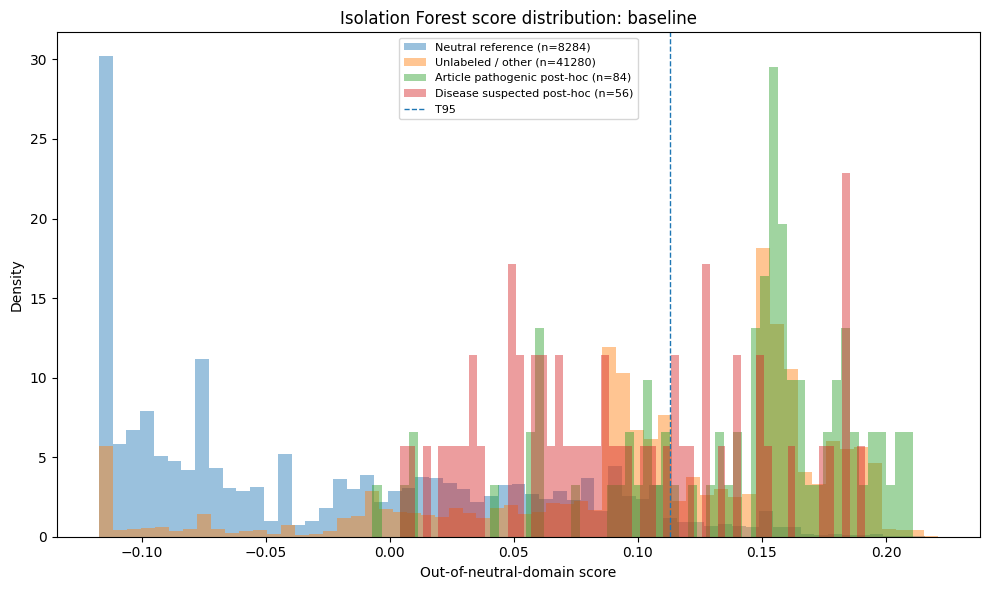

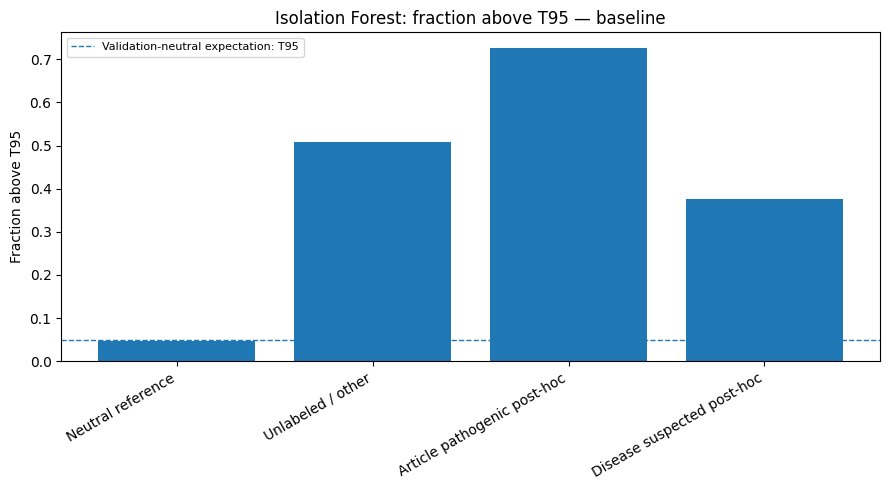

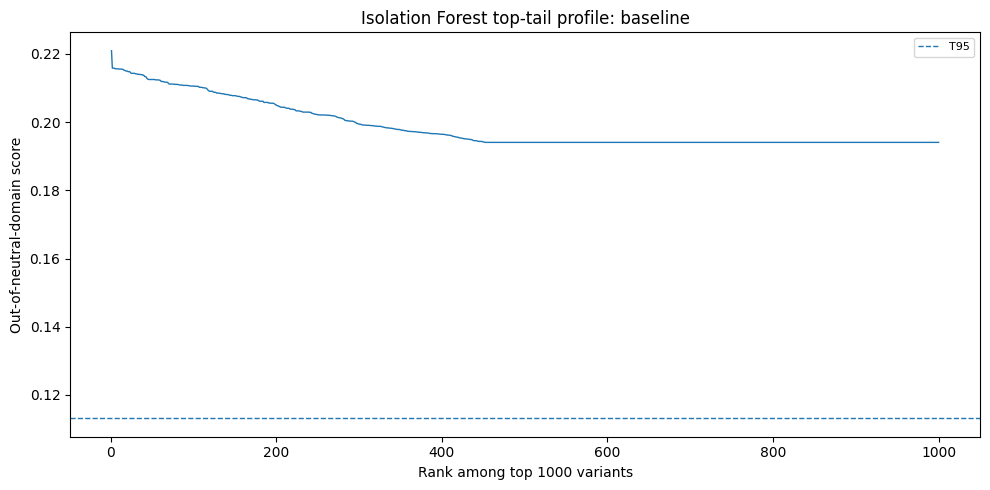


Enrichment plot table:
               analysis_group                             model_name  \
0           neutral_reference  codon_mod3_baseline__isolation_forest   
1          unlabeled_or_other  codon_mod3_baseline__isolation_forest   
2  article_pathogenic_posthoc  codon_mod3_baseline__isolation_forest   
3   disease_suspected_posthoc  codon_mod3_baseline__isolation_forest   

           feature_set        base_model threshold_name  n_group  \
0  codon_mod3_baseline  isolation_forest            T95     8284   
1  codon_mod3_baseline  isolation_forest            T95    41280   
2  codon_mod3_baseline  isolation_forest            T95       84   
3  codon_mod3_baseline  isolation_forest            T95       56   

   n_above_threshold  fraction_above_threshold  \
0                396                  0.047803   
1              20935                  0.507146   
2                 61                  0.726190   
3                 21                  0.375000   

   expected_validation_

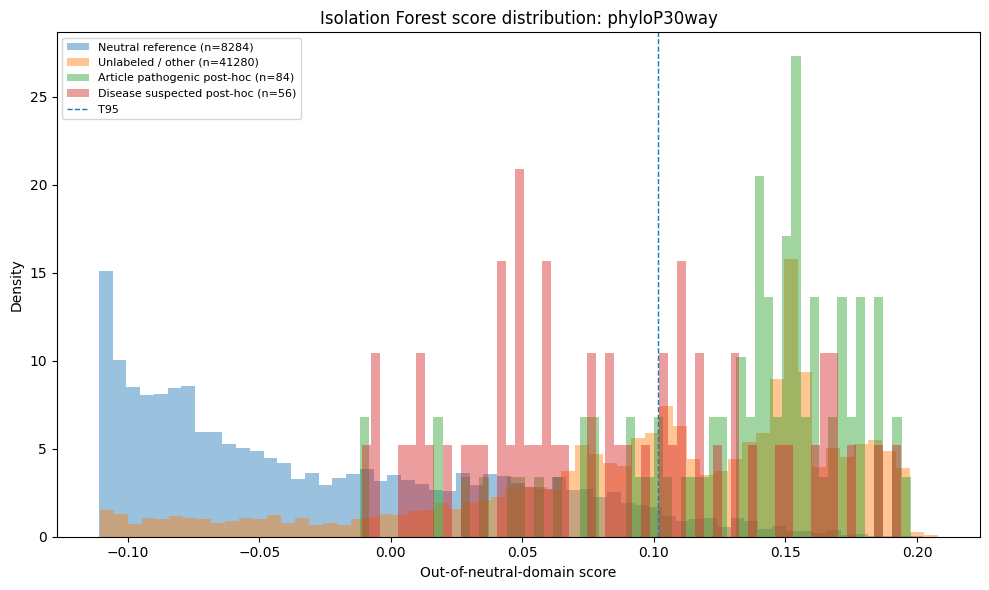

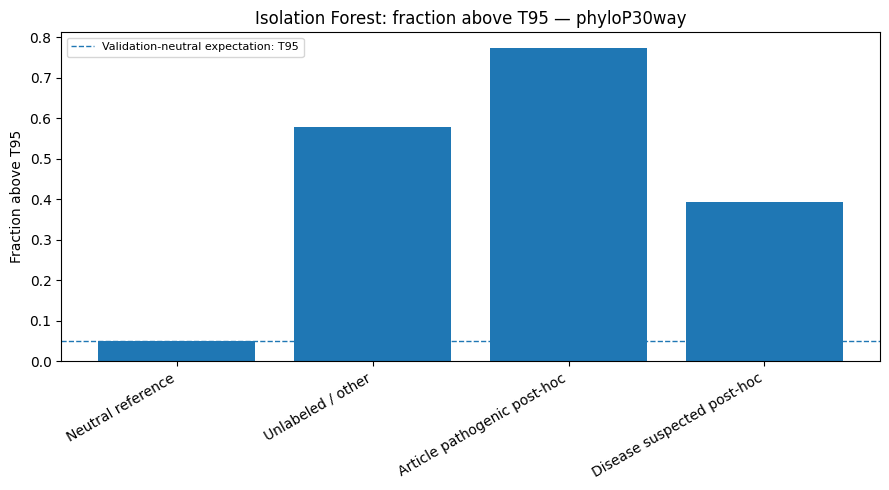

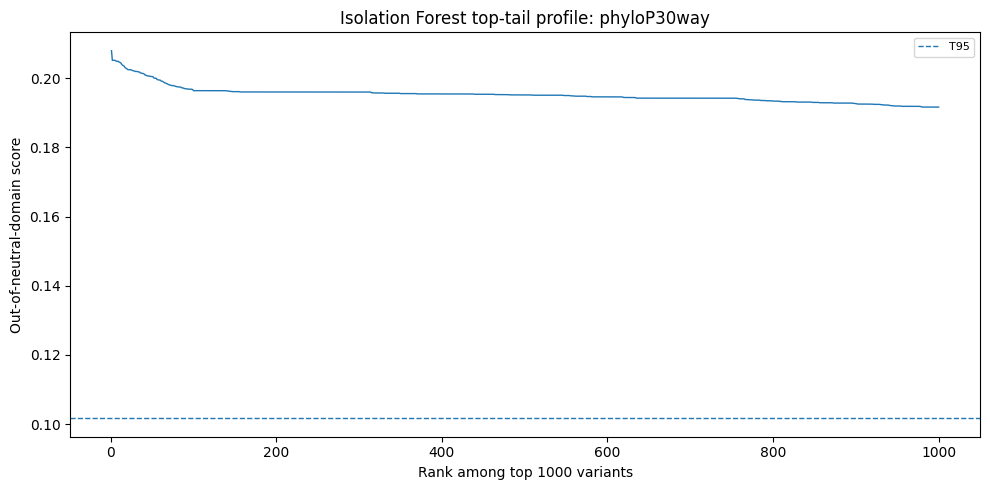


Enrichment plot table:
               analysis_group                                     model_name  \
0           neutral_reference  codon_mod3_plus_phyloP30way__isolation_forest   
1          unlabeled_or_other  codon_mod3_plus_phyloP30way__isolation_forest   
2  article_pathogenic_posthoc  codon_mod3_plus_phyloP30way__isolation_forest   
3   disease_suspected_posthoc  codon_mod3_plus_phyloP30way__isolation_forest   

                   feature_set        base_model threshold_name  n_group  \
0  codon_mod3_plus_phyloP30way  isolation_forest            T95     8284   
1  codon_mod3_plus_phyloP30way  isolation_forest            T95    41280   
2  codon_mod3_plus_phyloP30way  isolation_forest            T95       84   
3  codon_mod3_plus_phyloP30way  isolation_forest            T95       56   

   n_above_threshold  fraction_above_threshold  \
0                418                  0.050459   
1              23863                  0.578077   
2                 65                  0.7738

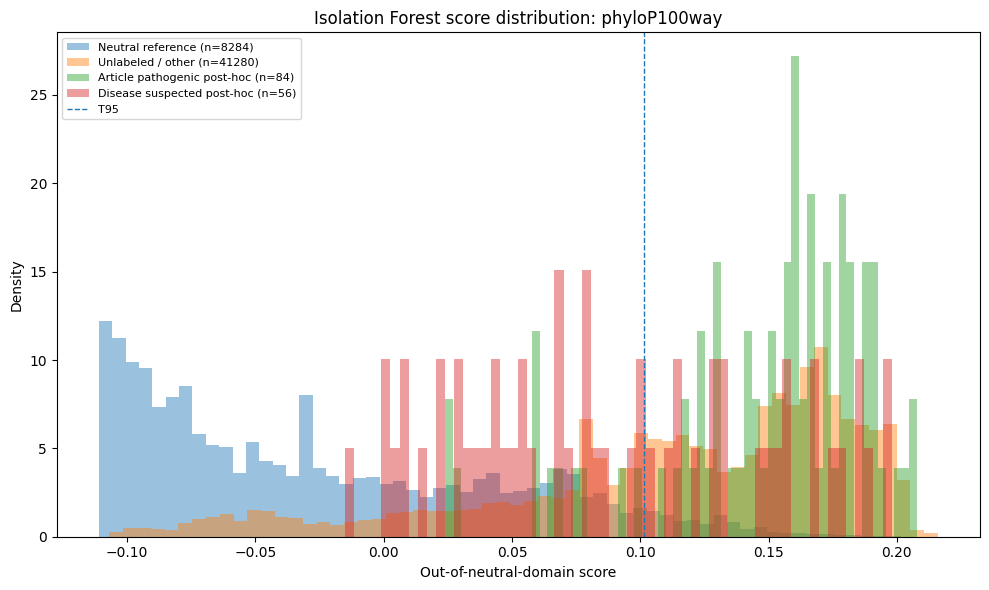

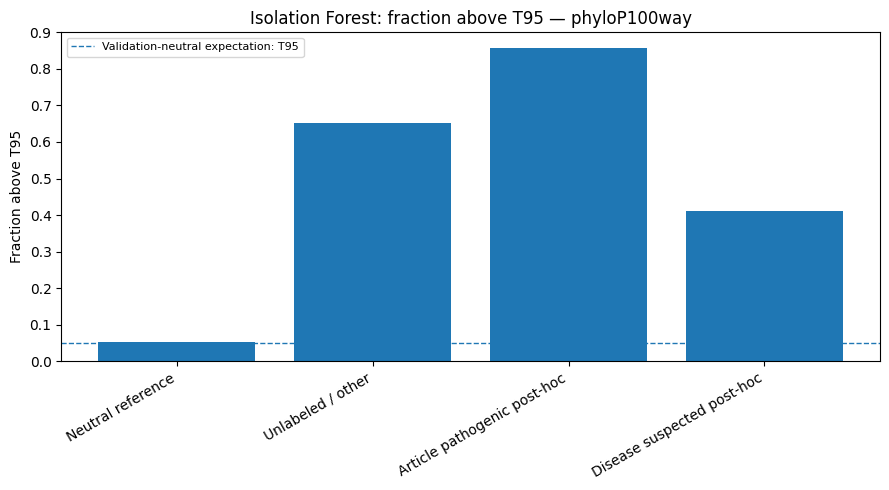

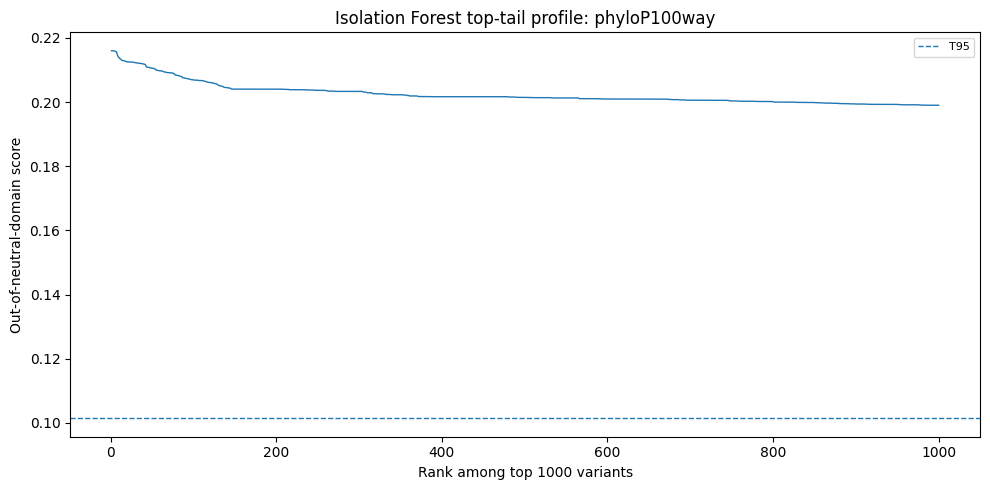


Enrichment plot table:
               analysis_group                                      model_name  \
0           neutral_reference  codon_mod3_plus_phyloP100way__isolation_forest   
1          unlabeled_or_other  codon_mod3_plus_phyloP100way__isolation_forest   
2  article_pathogenic_posthoc  codon_mod3_plus_phyloP100way__isolation_forest   
3   disease_suspected_posthoc  codon_mod3_plus_phyloP100way__isolation_forest   

                    feature_set        base_model threshold_name  n_group  \
0  codon_mod3_plus_phyloP100way  isolation_forest            T95     8284   
1  codon_mod3_plus_phyloP100way  isolation_forest            T95    41280   
2  codon_mod3_plus_phyloP100way  isolation_forest            T95       84   
3  codon_mod3_plus_phyloP100way  isolation_forest            T95       56   

   n_above_threshold  fraction_above_threshold  \
0                429                  0.051787   
1              26937                  0.652544   
2                 72              

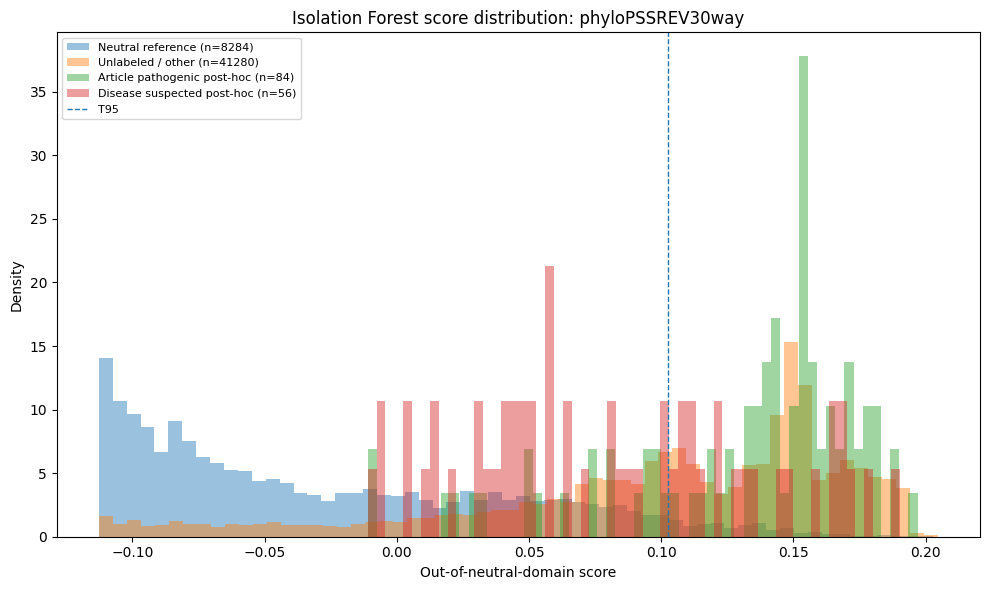

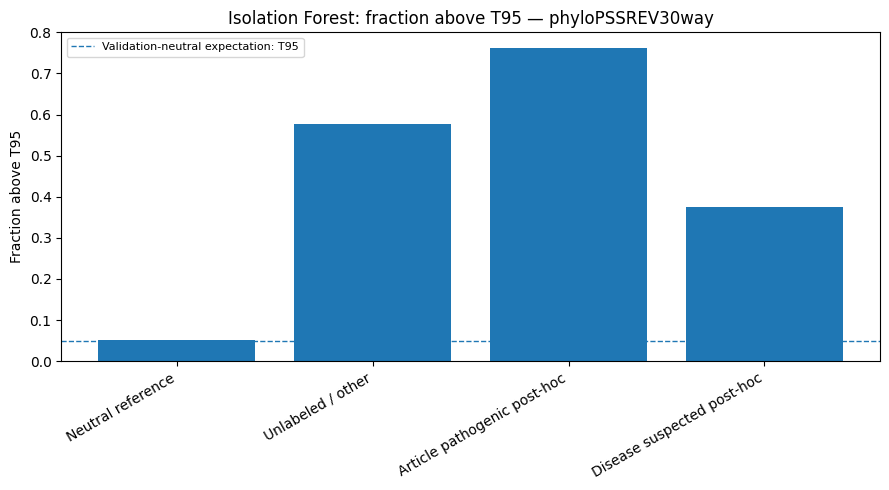

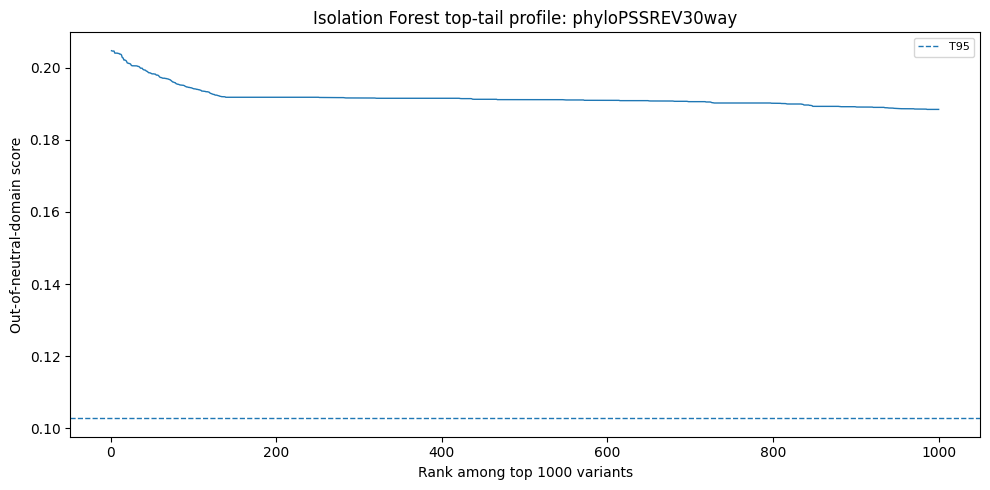


Enrichment plot table:
               analysis_group  \
0           neutral_reference   
1          unlabeled_or_other   
2  article_pathogenic_posthoc   
3   disease_suspected_posthoc   

                                          model_name  \
0  codon_mod3_plus_phyloPSSREV30way__isolation_fo...   
1  codon_mod3_plus_phyloPSSREV30way__isolation_fo...   
2  codon_mod3_plus_phyloPSSREV30way__isolation_fo...   
3  codon_mod3_plus_phyloPSSREV30way__isolation_fo...   

                        feature_set        base_model threshold_name  n_group  \
0  codon_mod3_plus_phyloPSSREV30way  isolation_forest            T95     8284   
1  codon_mod3_plus_phyloPSSREV30way  isolation_forest            T95    41280   
2  codon_mod3_plus_phyloPSSREV30way  isolation_forest            T95       84   
3  codon_mod3_plus_phyloPSSREV30way  isolation_forest            T95       56   

   n_above_threshold  fraction_above_threshold  \
0                423                  0.051062   
1              23865   

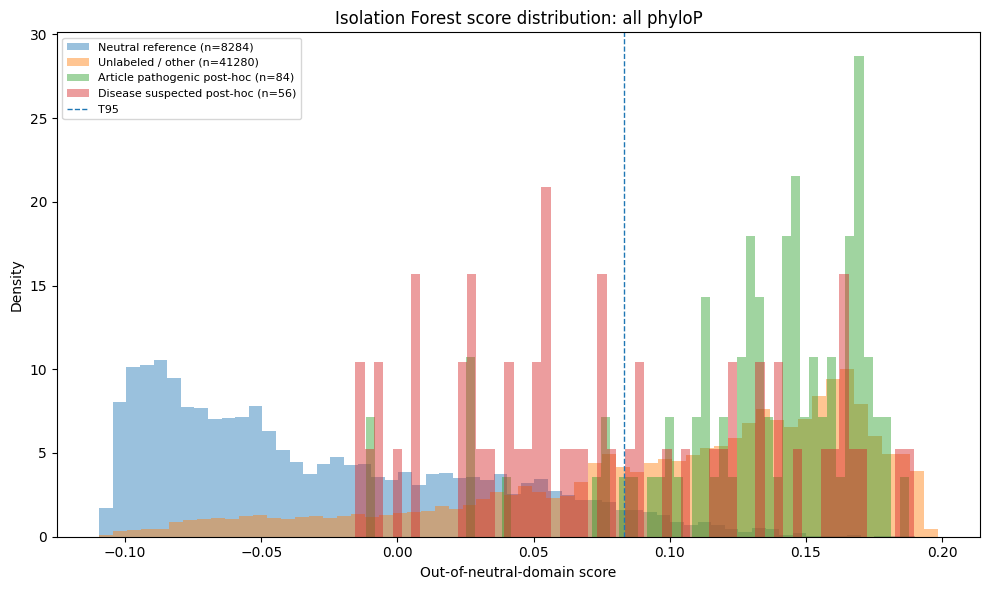

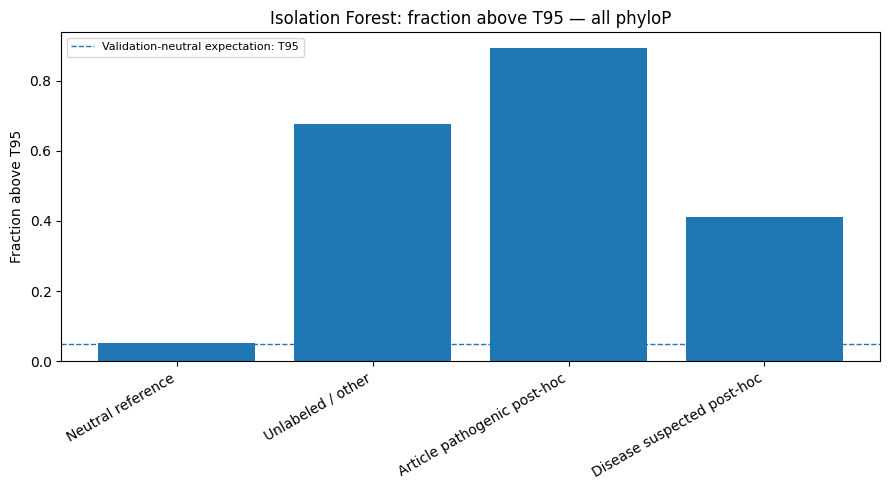

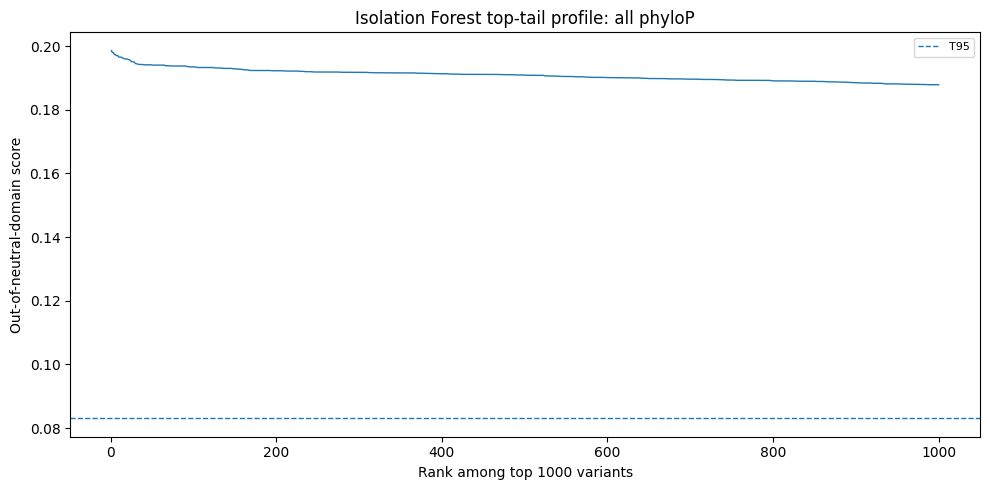


Enrichment plot table:
               analysis_group                                    model_name  \
0           neutral_reference  codon_mod3_plus_all_phyloP__isolation_forest   
1          unlabeled_or_other  codon_mod3_plus_all_phyloP__isolation_forest   
2  article_pathogenic_posthoc  codon_mod3_plus_all_phyloP__isolation_forest   
3   disease_suspected_posthoc  codon_mod3_plus_all_phyloP__isolation_forest   

                  feature_set        base_model threshold_name  n_group  \
0  codon_mod3_plus_all_phyloP  isolation_forest            T95     8284   
1  codon_mod3_plus_all_phyloP  isolation_forest            T95    41280   
2  codon_mod3_plus_all_phyloP  isolation_forest            T95       84   
3  codon_mod3_plus_all_phyloP  isolation_forest            T95       56   

   n_above_threshold  fraction_above_threshold  \
0                439                  0.052994   
1              27970                  0.677568   
2                 75                  0.892857   
3   

In [21]:
# ============================================================
# Generate old-style plots for Isolation Forest phyloP models
# No figure saving
# ============================================================

for feature_set_name in phylo_if_feature_order:
    model_name = get_isolation_forest_model_name(feature_set_name)

    if model_name not in score_specs:
        print(f"Skipping missing model: {model_name}")
        continue

    print(f"\nPlotting: {model_name}")

    plot_if_score_distribution_T95(
        scored=scored,
        threshold_df=threshold_df,
        feature_set_name=feature_set_name,
    )

    enrichment_plot_df = plot_if_enrichment_T95(
        enrichment_df=enrichment_df,
        feature_set_name=feature_set_name,
    )

    top_tail_df = plot_if_top_tail_T95(
        scored=scored,
        threshold_df=threshold_df,
        feature_set_name=feature_set_name,
        top_n=1000,
    )

    print("\nEnrichment plot table:")
    print(enrichment_plot_df)